# 02 - Modeling: Isolation Forest baseline vs GRU autoencoder vs ensemble

All models are trained on **benign Monday traffic only**. Thresholds and hyper-parameters are chosen on **Tuesday + Wednesday** (validation). All numbers reported below are on **Thursday + Friday** (test), which contain attack families the models never saw.

The **ensemble** averages the standardised log-scores of the GRU autoencoder and the Isolation Forest, so a window is flagged when either detector (or both) finds it unusual.

Run `01_eda_preprocessing.ipynb` first (it writes `data/processed/sequences.npz`).

In [1]:
import sys; sys.path.append("..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from src.config import *
from src.pipeline import load_splits
from src.preprocessing import FlowPreprocessor
from src.experiment import run_experiment, export_artifacts, quick_gru_val_score
from src.evaluate import per_attack_table
sns.set_style("whitegrid")
import joblib
from src.models import load_model, reconstruction_errors
from src.baseline import window_scores
splits = load_splits()
pre = FlowPreprocessor.load(MODEL_DIR / "preprocessor.joblib")
print({k: splits[k].shape for k in ["X_train", "X_val", "X_test"]})

{'X_train': (105889, 10, 37), 'X_val': (113703, 10, 37), 'X_test': (116119, 10, 37)}


## 1. Hyper-parameter search (validation days only)
Short 8-epoch runs; the score is PR-AUC on the validation days (base rate of attacks there is the reference: a score near it means no skill). The test days are never touched here. If a different setting wins, update `HIDDEN` / `LATENT` in `src/config.py` before the final run.

In [2]:
grid = [(64, 16), (128, 32), (256, 64)]
tuning = pd.DataFrame(
    [{"hidden": h, "latent": l, "val_pr_auc": quick_gru_val_score(splits, h, l)} for h, l in grid])
tuning
# reference: attack share of the validation windows
print(f"attack base rate on validation: {splits['y_val'].mean():.3f}")

attack base rate on validation: 0.302


In [3]:
tuning 

,hidden,latent,val_pr_auc
0,64,16,0.640156
1,128,32,0.711340
2,256,64,0.752784


## 2. Train both models and evaluate

In [4]:
res = run_experiment(splits, epochs=EPOCHS)

Isolation Forest on 476,500 benign flows ...
GRU autoencoder on 95,299 benign windows ...
epoch 01  train 0.6391  val 0.4716
epoch 02  train 0.4183  val 0.3642
epoch 03  train 0.3337  val 0.3135
epoch 04  train 0.2736  val 0.2458
epoch 05  train 0.2217  val 0.1956
epoch 06  train 0.1836  val 0.1649
epoch 07  train 0.1537  val 0.1421
epoch 08  train 0.1345  val 0.1257
epoch 09  train 0.1205  val 0.1141
epoch 10  train 0.1100  val 0.1031
epoch 11  train 0.1009  val 0.0937
epoch 12  train 0.0927  val 0.0865
epoch 13  train 0.0864  val 0.0857
epoch 14  train 0.0807  val 0.0804
epoch 15  train 0.0756  val 0.0710
epoch 16  train 0.0705  val 0.0663
epoch 17  train 0.0663  val 0.0653
epoch 18  train 0.0625  val 0.0607
epoch 19  train 0.0589  val 0.0566
epoch 20  train 0.0559  val 0.0537
epoch 21  train 0.0526  val 0.0528
epoch 22  train 0.0501  val 0.0501
epoch 23  train 0.0480  val 0.0466
epoch 24  train 0.0459  val 0.0453
epoch 25  train 0.0441  val 0.0446
epoch 26  train 0.0427  val 0.0439


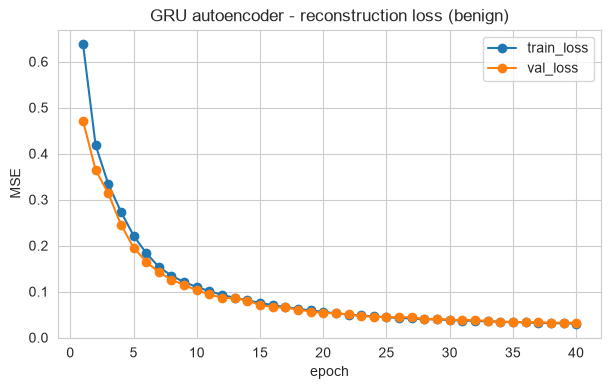

In [5]:
res["history"].plot(x="epoch", y=["train_loss", "val_loss"], figsize=(7, 4), marker="o",
                    title="GRU autoencoder - reconstruction loss (benign)")
plt.ylabel("MSE"); plt.show()

## 3. Results on the unseen test days
Three threshold rules, all fixed **before** looking at test data:
* `val_f1` - threshold maximising F1 on the validation days (uses attack labels).
* `pct99` / `pct95` - 99th / 95th percentile of benign validation scores (need no attack labels; aim for about 1 % / 5 % false alarms on normal traffic).

The table that follows shows the precision/recall trade-off for several false-alarm budgets. Use it to choose the operating point for the app.

The `ensemble` rows combine both detectors; its z-scored threshold is also fixed on the validation days only.

In [6]:
res["table"].round(4)

,model,threshold_rule,threshold,roc_auc,pr_auc,precision,recall,f1,fpr,tp,fp,fn,tn
0,isolation_forest,val_f1,0.4897,0.8576,0.5688,0.5356,0.9288,0.6794,0.3103,29996,26010,2299,57814
1,isolation_forest,pct99,0.5264,0.8576,0.5688,0.6479,0.3721,0.4727,0.0779,12018,6531,20277,77293
2,isolation_forest,pct95,0.5083,0.8576,0.5688,0.6179,0.6802,0.6475,0.1621,21966,13584,10329,70240
3,gru_ae,val_f1,0.0946,0.8575,0.5360,0.6741,0.8964,0.7695,0.1670,28950,13997,3345,69827
4,gru_ae,pct99,0.2074,0.8575,0.5360,0.7016,0.7748,0.7364,0.1270,25023,10642,7272,73182
5,gru_ae,pct95,0.1194,0.8575,0.5360,0.6921,0.8712,0.7714,0.1493,28136,12519,4159,71305
6,ensemble,val_f1,1.2049,0.8686,0.5641,0.6466,0.9128,0.7570,0.1922,29478,16113,2817,67711
7,ensemble,pct99,2.0117,0.8686,0.5641,0.7062,0.7961,0.7485,0.1276,25711,10695,6584,73129
8,ensemble,pct95,1.4518,0.8686,0.5641,0.6794,0.8912,0.7710,0.1620,28780,13581,3515,70243


In [7]:
from src.evaluate import operating_points
for name in res["scores"]["val"]:
    print(name)
    display(operating_points(splits["y_val"], res["scores"]["val"][name],
                             splits["y_test"], res["scores"]["test"][name]).round(4))

isolation_forest


,target_fpr,threshold,precision,recall,f1,fpr,tp,fp,fn,tn
0,0.01,0.5264,0.6479,0.3721,0.4727,0.0779,12018,6531,20277,77293
1,0.02,0.5189,0.6457,0.4997,0.5634,0.1056,16138,8854,16157,74970
2,0.05,0.5083,0.6179,0.6802,0.6475,0.1621,21966,13584,10329,70240
3,0.10,0.4993,0.5997,0.9037,0.7210,0.2324,29186,19482,3109,64342
4,0.20,0.4885,0.5283,0.9310,0.6741,0.3203,30068,26848,2227,56976


gru_ae


,target_fpr,threshold,precision,recall,f1,fpr,tp,fp,fn,tn
0,0.01,0.2074,0.7016,0.7748,0.7364,0.1270,25023,10642,7272,73182
1,0.02,0.1693,0.6989,0.8050,0.7482,0.1336,25997,11202,6298,72622
2,0.05,0.1194,0.6921,0.8712,0.7714,0.1493,28136,12519,4159,71305
3,0.10,0.0904,0.6686,0.8986,0.7667,0.1716,29019,14384,3276,69440
4,0.20,0.0658,0.6181,0.9273,0.7417,0.2208,29946,18506,2349,65318


ensemble


,target_fpr,threshold,precision,recall,f1,fpr,tp,fp,fn,tn
0,0.01,2.0117,0.7062,0.7961,0.7485,0.1276,25711,10695,6584,73129
1,0.02,1.7757,0.7008,0.8411,0.7645,0.1384,27164,11600,5131,72224
2,0.05,1.4518,0.6794,0.8912,0.7710,0.1620,28780,13581,3515,70243
3,0.10,1.1640,0.6401,0.9148,0.7532,0.1982,29545,16612,2750,67212
4,0.20,0.8022,0.5697,0.9323,0.7072,0.2713,30109,22742,2186,61082


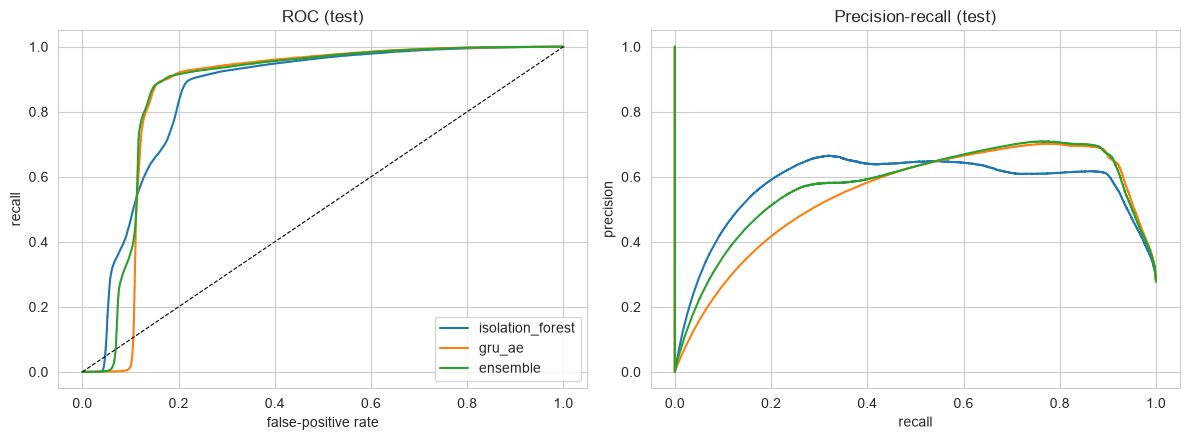

In [8]:
y = splits["y_test"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, s in res["scores"]["test"].items():
    fpr, tpr, _ = roc_curve(y, s);  ax[0].plot(fpr, tpr, label=name)
    p, r, _ = precision_recall_curve(y, s);  ax[1].plot(r, p, label=name)
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set(title="ROC (test)", xlabel="false-positive rate", ylabel="recall")
ax[1].set(title="Precision-recall (test)", xlabel="recall", ylabel="precision")
ax[0].legend(); plt.tight_layout(); plt.show()

## 4. Which attacks are caught?
Share of windows flagged per class at the `val_f1` threshold. For BENIGN this is the false-positive rate; for attacks it is the detection rate.

In [9]:
cmp = None
for name, s in res["scores"]["test"].items():
    thr = res["thresholds"][name]["val_f1"]
    t = per_attack_table(splits["t_test"], splits["classes"], s, thr).set_index("class")["flagged_%"].rename(name)
    cmp = t.to_frame() if cmp is None else cmp.join(t)
cmp.sort_values(cmp.columns[-1], ascending=False)

,isolation_forest,gru_ae,ensemble
class,,,
DDoS,99.37,95.40,98.95
PortScan,97.79,98.66,98.33
Infiltration,47.22,47.22,44.44
BENIGN,31.03,16.70,19.22
Web Attack - Brute Force,40.82,8.91,14.88
Bot,25.58,11.92,14.50
Web Attack - XSS,40.14,5.73,11.47
Web Attack - Sql Injection,25.00,5.00,10.00


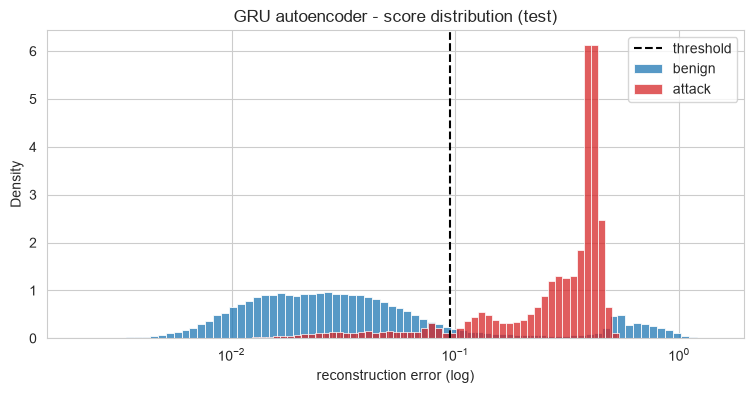

In [10]:
s = res["scores"]["test"]["gru_ae"]; thr = res["thresholds"]["gru_ae"]["val_f1"]
plt.figure(figsize=(9, 4))
sns.histplot(s[y == 0], bins=80, log_scale=True, stat="density", color="tab:blue", label="benign")
sns.histplot(s[y == 1], bins=80, log_scale=True, stat="density", color="tab:red", label="attack")
plt.axvline(thr, color="k", ls="--", label="threshold")
plt.xlabel("reconstruction error (log)"); plt.title("GRU autoencoder - score distribution (test)")
plt.legend(); plt.show()

## 5. Baseline vs sequence model - discussion
*Fill in after running (these are the points the evaluators will ask about):*
* Which model has the higher PR-AUC / F1 on the unseen test days, and by how much?
* Which attack families does the GRU catch that the Isolation Forest misses (and vice versa)? See section 4.
* False-positive rate of the final model: how many false alarms per 1,000 normal windows?
* Why the final model was chosen, and what it cannot do (limitations: slow, stealthy attacks such as Infiltration or Heartbleed have very few samples; a threshold tuned on one day may drift).

## 6. Error analysis: where do the false alarms come from?
The score histogram showed a group of "benign" windows with a very high error, and both ROC curves stay flat until a false-positive rate of about 10 %. This section finds out what those windows are.

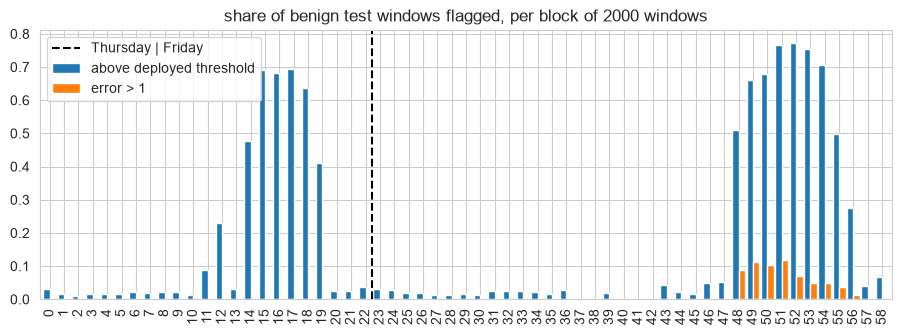

In [11]:
from src.data_loader import load_clean
df = load_clean()
N_THU = int((df["day"] == "Thursday").sum()) // WINDOW    # Thursday windows come first in the test array, then Friday

s_g = res["scores"]["test"]["gru_ae"]
X, y = splits["X_test"], splits["y_test"]
thr_g = res["thresholds"]["gru_ae"]["pct95"]

# 1) WHEN do the false alarms happen? (share of benign windows flagged, per block of 2000 test windows)
b = np.where(y == 0)[0]
blocks = b // 2000
share = pd.DataFrame({"above deployed threshold": pd.Series(s_g[b] > thr_g).groupby(blocks).mean(),
                      "error > 1": pd.Series(s_g[b] > 1.0).groupby(blocks).mean()})
share.plot(kind="bar", figsize=(11, 3.5), width=0.9, title="share of benign test windows flagged, per block of 2000 windows")
plt.axvline(N_THU / 2000 - 0.5, color="k", ls="--", label="Thursday | Friday"); plt.legend(); plt.show()

In [12]:
# 2) WHICH features make those windows look odd?
bad = (y == 0) & (s_g > 1.0)
print(f"benign windows with error > 1: {bad.sum():,} = {bad.sum() / (y == 0).sum():.1%} of benign")
hi = np.abs(X[bad]).mean(axis=(0, 1))
ok = np.abs(X[(y == 0) & (s_g < 0.2)]).mean(axis=(0, 1))
d = pd.DataFrame({"feature": pre.features_, "mean_abs_z_high_error": hi, "mean_abs_z_normal": ok})
display(d.sort_values("mean_abs_z_high_error", ascending=False).head(10).round(2))

benign windows with error > 1: 357 = 0.4% of benign


,feature,mean_abs_z_high_error,mean_abs_z_normal
30,Down/Up Ratio,2.87,0.93
29,URG Flag Count,2.58,0.61
8,Fwd Packet Length Mean,2.22,0.72
19,Bwd IAT Std,2.12,0.84
35,Active Mean,1.84,0.74
0,Destination Port,1.82,0.74
18,Bwd IAT Total,1.74,0.84
5,Total Length of Fwd Packets,1.66,0.66
9,Fwd Packet Length Std,1.51,0.86
28,ACK Flag Count,1.48,0.89


In [13]:
# 3) WHO are the hosts in those windows? (map test windows back to the raw flows)
fri = df[df["day"] == "Friday"].reset_index(drop=True)
bad_idx = np.where(bad)[0]
fri_win = bad_idx[bad_idx >= N_THU] - N_THU
rows = (fri_win[:, None] * WINDOW + np.arange(WINDOW)).ravel()
flows = fri.iloc[rows]
print("Friday windows with high-error benign traffic:", len(fri_win), "of", len(bad_idx))
print("their time span:", flows["Timestamp"].min(), "->", flows["Timestamp"].max())
for col in ["Source IP", "Destination IP", "Destination Port"]:
    print(f"\ntop {col}:\n", flows[col].value_counts().head(5).to_string())
atk = fri[fri["is_attack"] == 1]
print("\nFriday attack flows by type:\n", atk.groupby("Label")["Timestamp"].agg(["min", "max", "count"]).to_string())

Friday windows with high-error benign traffic: 355 of 357
their time span: 2017-07-07 09:00:00 -> 2017-07-07 16:16:00

top Source IP:
 Source IP
192.168.10.50    3529
192.168.10.25       8
192.168.10.17       6
192.168.10.3        3
192.168.10.9        1

top Destination IP:
 Destination IP
172.16.0.1        3520
192.168.10.3        13
192.168.10.255       5
224.0.0.251          2
192.168.10.1         2

top Destination Port:
 Destination Port
53.0       8
137.0      5
389.0      3
138.0      3
51650.0    3

Friday attack flows by type:
                          min                 max   count
Label                                                   
Bot      2017-07-07 09:34:00 2017-07-07 12:59:00    1956
DDoS     2017-07-07 15:56:00 2017-07-07 16:16:00  128025
PortScan 2017-07-07 13:05:00 2017-07-07 15:23:00  158804


In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score
from src.evaluate import metrics_at_threshold
ATTACKER = "172.16.0.1"

def day_rows(day):
    d = df[df["day"] == day].reset_index(drop=True)
    return d.iloc[: len(d) // WINDOW * WINDOW]

td = pd.concat([day_rows("Thursday"), day_rows("Friday")], ignore_index=True)
assert len(td) == len(y) * WINDOW, "window/row alignment is off"
linked = ((td["Source IP"] == ATTACKER) | (td["Destination IP"] == ATTACKER)).to_numpy().reshape(-1, WINDOW).any(axis=1)
print(f"benign windows with a flow to/from the attacker IP: {((y == 0) & linked).sum():,} of {(y == 0).sum():,}")

rows = []
for name, s in res["scores"]["test"].items():
    thr = res["thresholds"][name]["pct95"]
    fa = (s > thr) & (y == 0)                              # false alarms
    keep = ~((y == 0) & linked)                            # drop "benign" windows that involve the attacker
    m_all, m_adj = metrics_at_threshold(y, s, thr), metrics_at_threshold(y[keep], s[keep], thr)
    rows.append({"model": name,
                 "FPR (all benign)": m_all["fpr"], "FPR (excl. attacker-linked)": m_adj["fpr"],
                 "false alarms linked to attacker": (fa & linked).sum() / max(fa.sum(), 1),
                 "F1 (all)": m_all["f1"], "F1 (excl.)": m_adj["f1"],
                 "ROC-AUC (excl.)": roc_auc_score(y[keep], s[keep]), "PR-AUC (excl.)": average_precision_score(y[keep], s[keep])})
pd.DataFrame(rows).round(3)

benign windows with a flow to/from the attacker IP: 4,237 of 83,824


,model,FPR (all benign),FPR (excl. attacker-linked),false alarms linked to attacker,F1 (all),F1 (excl.),ROC-AUC (excl.),PR-AUC (excl.)
0,isolation_forest,0.162,0.130,0.240,0.648,0.680,0.891,0.705
1,gru_ae,0.149,0.115,0.271,0.771,0.809,0.889,0.611
2,ensemble,0.162,0.128,0.248,0.771,0.807,0.902,0.666


*Write down what this shows (it is a good Q&A answer): which period the high-error benign windows fall in, whether it overlaps an attack period, and which hosts and features are involved.*

## 7. Export for the Streamlit app

In [14]:
# choose the app's default alert threshold from the table above: "val_f1", "pct95" or "pct99"
export_artifacts(pre, res, splits, default_rule="pct95")

from src.data_loader import load_clean
from src.make_demo import build_demo_files
print("demo streams:", build_demo_files(load_clean()))

RESULTS_DIR.mkdir(exist_ok=True)
res["table"].to_csv(RESULTS_DIR / "metrics_test.csv", index=False)
cmp.to_csv(RESULTS_DIR / "per_attack_flagged_pct.csv")
print(sorted(p.name for p in MODEL_DIR.iterdir()))

demo streams: ['demo_Bot.csv', 'demo_DDoS.csv', 'demo_Infiltration.csv', 'demo_PortScan.csv', 'demo_Web_Attack_Brute_Force.csv', 'demo_Web_Attack_Sql_Injection.csv', 'demo_Web_Attack_XSS.csv']
['gru_ae.pt', 'isolation_forest.joblib', 'preprocessor.joblib', 'threshold.json']
